In [1]:
# ! pip install ultralytics

In [ ]:
# IMPORTS: 

# ── IMPORTS ───────────────────────────────────────────────────────────────────
import os
import random
import shutil
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn.functional as F

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix
)

from ultralytics import YOLO

In [5]:
yaml_path = "/kaggle/input/datasets/marthaagonza/yaml-files/data.yaml"

with open(yaml_path, "r") as f:
    content = f.read()

print("=== Current content of data.yaml ===")
print(content)
print("==================================")

=== Current content of data.yaml ===
path: /kaggle/input/datasets/marthaagonza/augmented-128/augmented_horizontal_128   

train: train          
val:   val           

names:
  0: Parasitized
  1: Uninfected


In [2]:
import os
yaml_path = "/kaggle/working/data.yaml"

new_yaml = """path: /kaggle/input/datasets/marthaagonza/augmented-128/augmented_horizontal_128

train: .
val: .

names:
  0: Parasitized
  1: Uninfected
"""

with open(yaml_path, "w") as f:
    f.write(new_yaml)

print("data.yaml created successfully in /kaggle/working/")
print("Content:")
print(new_yaml)

data.yaml created successfully in /kaggle/working/
Content:
path: /kaggle/input/datasets/marthaagonza/augmented-128/augmented_horizontal_128

train: .
val: .

names:
  0: Parasitized
  1: Uninfected



In [3]:
source_root = Path("/kaggle/input/datasets/marthaagonza/augmented-128/augmented_horizontal_128")

dataset_root = Path("/kaggle/working/augmented_horizontal_128_split")
dataset_root.mkdir(parents=True, exist_ok=True)

classes = ["Parasitized", "Uninfected"]
train_ratio = 0.70   
val_ratio = 0.15     
test_ratio = 0.15    

random.seed(42)

for cls in classes:
    src_class_dir = source_root / cls
    if not src_class_dir.exists():
        print(f"Folder not found: {src_class_dir}")
        continue

    images = list(src_class_dir.glob("*.*"))
    random.shuffle(images)

    total = len(images)
    train_idx = int(total * train_ratio)
    val_idx = int(total * (train_ratio + val_ratio))

    train_imgs = images[:train_idx]
    val_imgs = images[train_idx:val_idx]
    test_imgs = images[val_idx:]

    (dataset_root / "train" / cls).mkdir(parents=True, exist_ok=True)
    (dataset_root / "val" / cls).mkdir(parents=True, exist_ok=True)
    (dataset_root / "test" / cls).mkdir(parents=True, exist_ok=True)

    print(f"Class '{cls}': {len(train_imgs)} train | {len(val_imgs)} val | {len(test_imgs)} test")

    for img in train_imgs:
        shutil.copy2(img, dataset_root / "train" / cls / img.name)
    for img in val_imgs:
        shutil.copy2(img, dataset_root / "val" / cls / img.name)
    for img in test_imgs:
        shutil.copy2(img, dataset_root / "test" / cls / img.name)

print("\n 70-15-15 Split completed successfully!")
print(f"Dataset saved at: {dataset_root}")
print(f"Total images per class ≈ 27,558 → Train: ~19,290 | Val: ~4,134 | Test: ~4,134")

Class 'Parasitized': 19290 train | 4134 val | 4134 test
Class 'Uninfected': 19290 train | 4134 val | 4134 test

 70-15-15 Split completed successfully!
Dataset saved at: /kaggle/working/augmented_horizontal_128_split
Total images per class ≈ 27,558 → Train: ~19,290 | Val: ~4,134 | Test: ~4,134


In [5]:
yaml_path = "/kaggle/working/data.yaml"

yaml_content = """path: /kaggle/working/augmented_horizontal_128_split

train: train
val: val

names:
  0: Parasitized
  1: Uninfected
"""

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print("data.yaml created with 70/15/15 structure!")
print(yaml_content)

data.yaml created with 70/15/15 structure!
path: /kaggle/working/augmented_horizontal_128_split

train: train
val: val

names:
  0: Parasitized
  1: Uninfected



In [6]:
yaml_path = "/kaggle/working/data.yaml"

with open(yaml_path, "r") as f:
    content = f.read()

print("=== Current content of data.yaml ===")
print(content)
print("==================================")

=== Current content of data.yaml ===
path: /kaggle/working/augmented_horizontal_128_split

train: train
val: val

names:
  0: Parasitized
  1: Uninfected



In [7]:
yaml_path = "/kaggle/working/data.yaml"

yaml_content = """path: /kaggle/working/augmented_horizontal_128_split

train: train
val: val

names:
  0: Parasitized
  1: Uninfected
"""

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print("Clean data.yaml created for 70-15-15 split")
print(yaml_content)

Clean data.yaml created for 70-15-15 split
path: /kaggle/working/augmented_horizontal_128_split

train: train
val: val

names:
  0: Parasitized
  1: Uninfected



In [16]:
import os
from pathlib import Path

base = Path("/kaggle/working/augmented_horizontal_128_split")

print("Checking structure:")
print("train exists:", (base / "train").exists())
print("val exists:", (base / "val").exists())
print("test exists:", (base / "test").exists())

for cls in ["Parasitized", "Uninfected"]:
    print(f"\nClass: {cls}")
    print("  Train images:", len(list((base / "train" / cls).glob("*.*"))) if (base / "train" / cls).exists() else "Missing")
    print("  Val images:  ", len(list((base / "val" / cls).glob("*.*"))) if (base / "val" / cls).exists() else "Missing")

Checking structure:
train exists: True
val exists: True
test exists: True

Class: Parasitized
  Train images: 19290
  Val images:   4134

Class: Uninfected
  Train images: 19290
  Val images:   4134


In [21]:
!pip install ultralytics opencv-python-headless -q

In [20]:
DATASET_PATH = "/kaggle/working/augmented_horizontal_128_split"  
PROJECT_NAME = "parasite_cls_128_70_15_15"
EPOCHS_TOTAL = 50
BATCH_SIZE = 24
MODEL_SIZE = "yolov8n-cls.pt"        

last_pt = f"/kaggle/working/runs/classify/{PROJECT_NAME}/weights/last.pt"

# ====================================================

if os.path.exists(last_pt):
    print(f" Resuming from previous checkpoint: {last_pt}")
    model = YOLO(last_pt)
else:
    print(f" Starting fresh training with {MODEL_SIZE}...")
    model = YOLO(MODEL_SIZE)

results = model.train(
    data=DATASET_PATH,                  # ← Direct folder path (this solves the error)
    epochs=EPOCHS_TOTAL,
    imgsz=128,
    batch=BATCH_SIZE,
    patience=20,
    augment=True,
    optimizer="AdamW",
    lr0=0.001,
    project="runs/classify",
    name=PROJECT_NAME,
    exist_ok=True,
    resume=os.path.exists(last_pt)
)

print("\n Training session completed!")
print(f"Best model saved at: {results.save_dir}/weights/best.pt")
print(f"Last checkpoint: {results.save_dir}/weights/last.pt")

🚀 Starting fresh training with yolov8n-cls.pt...
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=24, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/augmented_horizontal_128_split, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=parasite_cls_128_70_15_15, nbs=64, nms=False, op

In [26]:
import os
print(os.listdir("/kaggle/working/augmented_horizontal_128_split/train"))

['Parasitized', 'Uninfected']


In [24]:
import os

for root, dirs, files in os.walk("/kaggle/working"):
    for d in dirs:
        if d in ["Parasitized", "Uninfected"]:
            print(os.path.join(root, d))

/kaggle/working/yolo_malaria/dataset/train/Parasitized
/kaggle/working/yolo_malaria/dataset/train/Uninfected
/kaggle/working/yolo_malaria/dataset/val/Parasitized
/kaggle/working/yolo_malaria/dataset/val/Uninfected
/kaggle/working/yolo_malaria/dataset/test/Parasitized
/kaggle/working/yolo_malaria/dataset/test/Uninfected
/kaggle/working/augmented_horizontal_128_split/train/Parasitized
/kaggle/working/augmented_horizontal_128_split/train/Uninfected
/kaggle/working/augmented_horizontal_128_split/val/Parasitized
/kaggle/working/augmented_horizontal_128_split/val/Uninfected
/kaggle/working/augmented_horizontal_128_split/test/Parasitized
/kaggle/working/augmented_horizontal_128_split/test/Uninfected


In [28]:

test_dir = "/kaggle/working/augmented_horizontal_128_split/test"

for cls in os.listdir(test_dir):
    cls_path = os.path.join(test_dir, cls)
    files = os.listdir(cls_path)
    print(f"{cls}: {len(files)} files")
    if files:
        sample = os.path.join(cls_path, files[0])
        print(f"  sample     : {sample}")
        print(f"  is symlink : {os.path.islink(sample)}")
        print(f"  exists     : {os.path.exists(sample)}")
        if os.path.islink(sample):
            print(f"  points to  : {os.readlink(sample)}")

Parasitized: 4134 files
  sample     : /kaggle/working/augmented_horizontal_128_split/test/Parasitized/C182P143NThinF_IMG_20151201_171905_cell_147.png
  is symlink : False
  exists     : True
Uninfected: 4134 files
  sample     : /kaggle/working/augmented_horizontal_128_split/test/Uninfected/C175P136NThinF_IMG_20151127_141253_cell_167_flip1.png
  is symlink : False
  exists     : True


In [29]:
best_pt  = "/kaggle/working/runs/classify/runs/classify/parasite_cls_128_70_15_15/weights/best.pt"
test_dir = "/kaggle/working/augmented_horizontal_128_split/test"
IMG_SIZE = 128

model        = YOLO(best_pt)
total_params = sum(p.numel() for p in model.model.parameters())
CLASS_NAMES  = list(model.names.values())
print(f"Parameters : {total_params:,}")
print(f"Classes    : {CLASS_NAMES}")

y_pred, y_true, img_paths_out = [], [], []

for cls_name in os.listdir(test_dir):
    cls_folder = os.path.join(test_dir, cls_name)
    if not os.path.isdir(cls_folder):
        continue
    true_cls = CLASS_NAMES.index(cls_name)

    for result in model.predict(source=cls_folder, imgsz=IMG_SIZE,
                                 save=False, verbose=False, stream=True):
        y_pred.append(int(result.probs.top1))
        y_true.append(true_cls)
        img_paths_out.append(result.path)

y_pred        = np.array(y_pred)
y_true        = np.array(y_true)
img_paths_out = np.array(img_paths_out)

acc = accuracy_score(y_true, y_pred)
print(f"\nTest Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_true, y_pred)}")
print(f"\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Parameters : 1,440,850
Classes    : ['Parasitized', 'Uninfected']

Test Accuracy : 0.9771  (97.71%)

Confusion Matrix:
[[4008  126]
 [  63 4071]]

Classification Report:
              precision    recall  f1-score   support

 Parasitized       0.98      0.97      0.98      4134
  Uninfected       0.97      0.98      0.98      4134

    accuracy                           0.98      8268
   macro avg       0.98      0.98      0.98      8268
weighted avg       0.98      0.98      0.98      8268



In [8]:
results_csv = "/kaggle/working/runs/classify/runs/classify/parasite_cls_128_70_15_15/results.csv"
df = pd.read_csv(results_csv)

df.columns = df.columns.str.strip()
print(df.columns.tolist()) 

['epoch', 'time', 'train/loss', 'metrics/accuracy_top1', 'metrics/accuracy_top5', 'val/loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


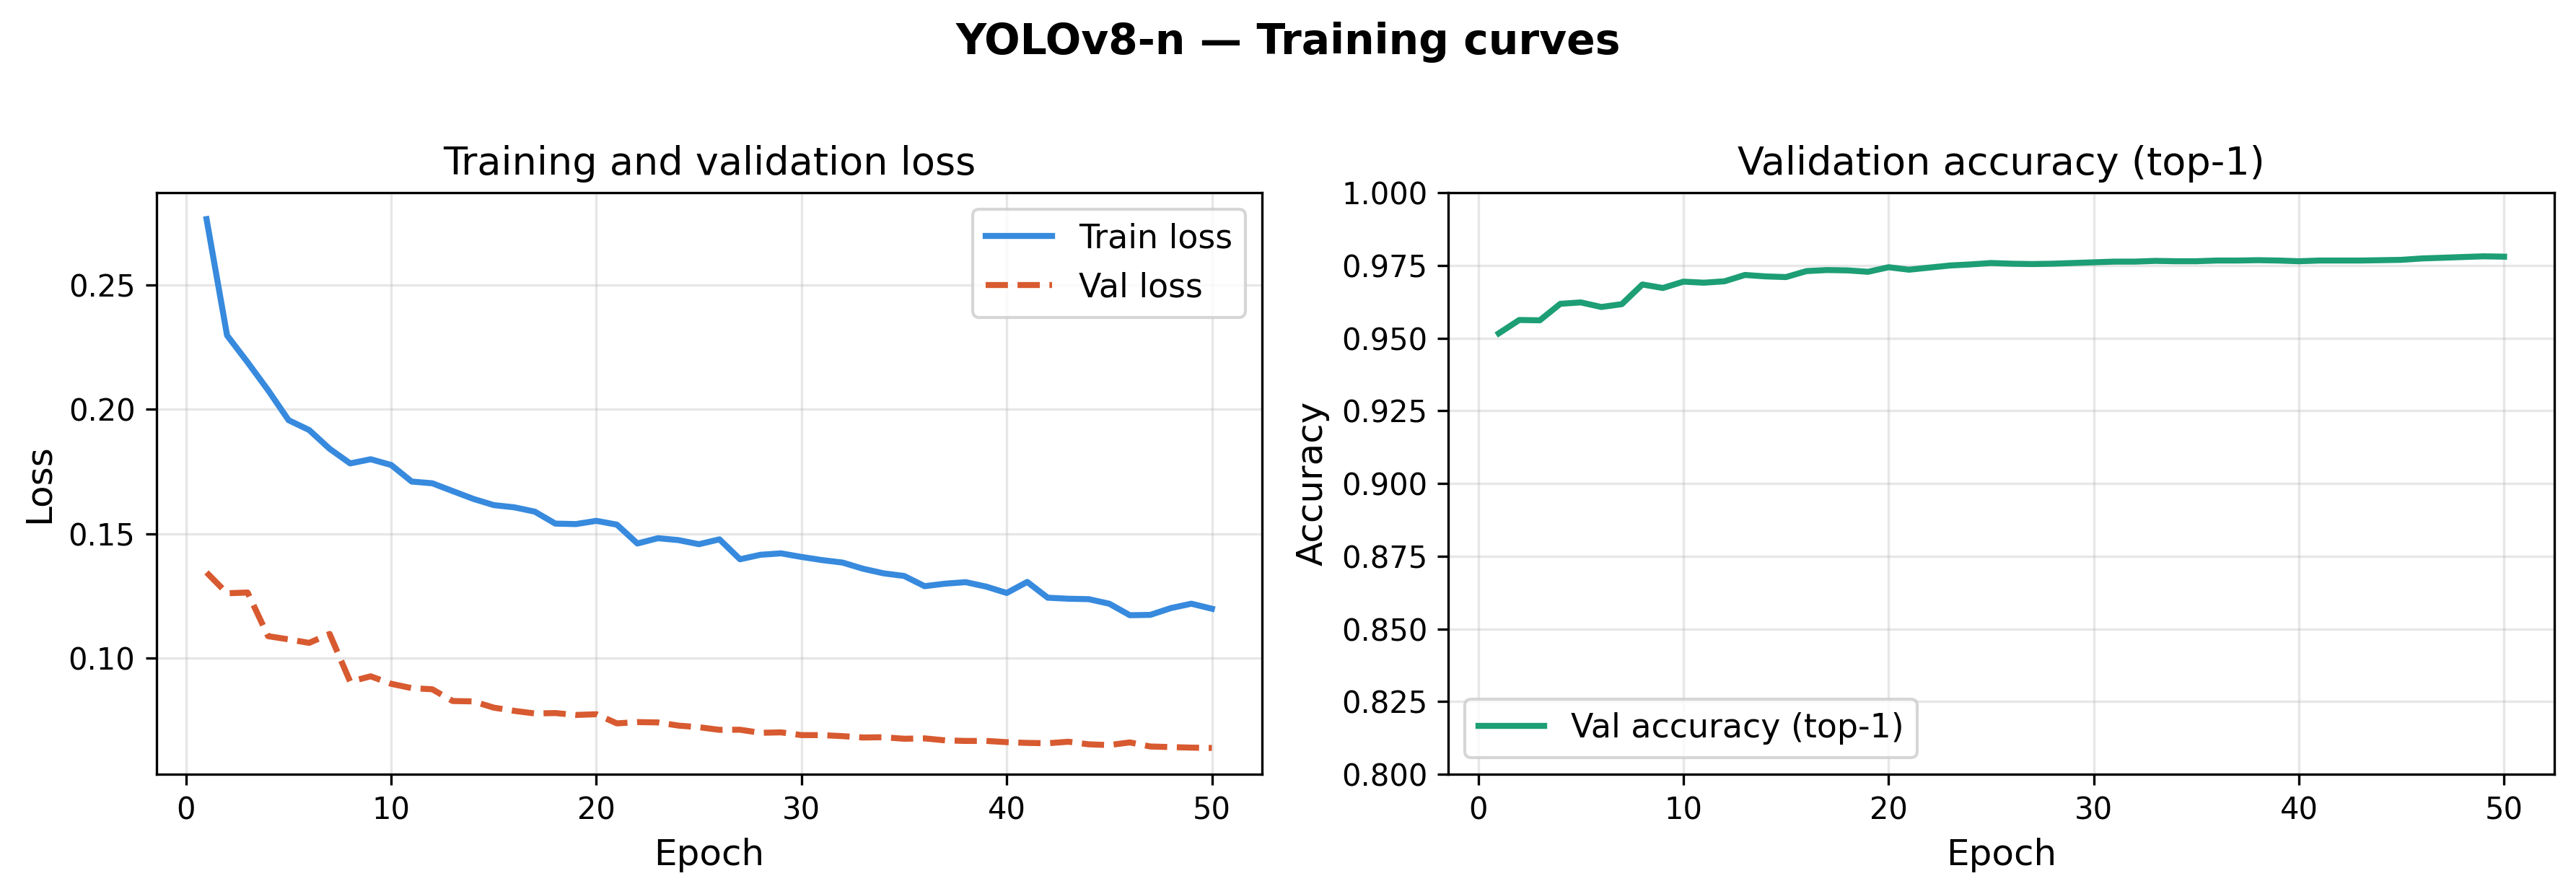

Saved: /kaggle/working/yolo_malaria/training_curves.png


/kaggle/working/yolo_malaria/training_curves.png

In [9]:
results_csv = "/kaggle/working/runs/classify/runs/classify/parasite_cls_128_70_15_15/results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=300)

# ── Loss curve ────────────────────────────────────────────────────────────
axes[0].plot(df['epoch'], df['train/loss'], label='Train loss', 
             color='#378ADD', linewidth=2)
axes[0].plot(df['epoch'], df['val/loss'],   label='Val loss',   
             color='#D85A30', linewidth=2, linestyle='--')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and validation loss', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['epoch'], df['metrics/accuracy_top1'], label='Val accuracy (top-1)',
             color='#1D9E75', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Validation accuracy (top-1)', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0.8, 1.0])

plt.suptitle('YOLOv8-n — Training curves', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

out_path = "/kaggle/working/yolo_malaria/training_curves.png"
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: {out_path}")

from IPython.display import FileLink, display
display(FileLink("/kaggle/working/yolo_malaria/training_curves.png"))

## Grad-CAM (Gradient-weighted Class Activation Mapping) 

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Hooked: Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)


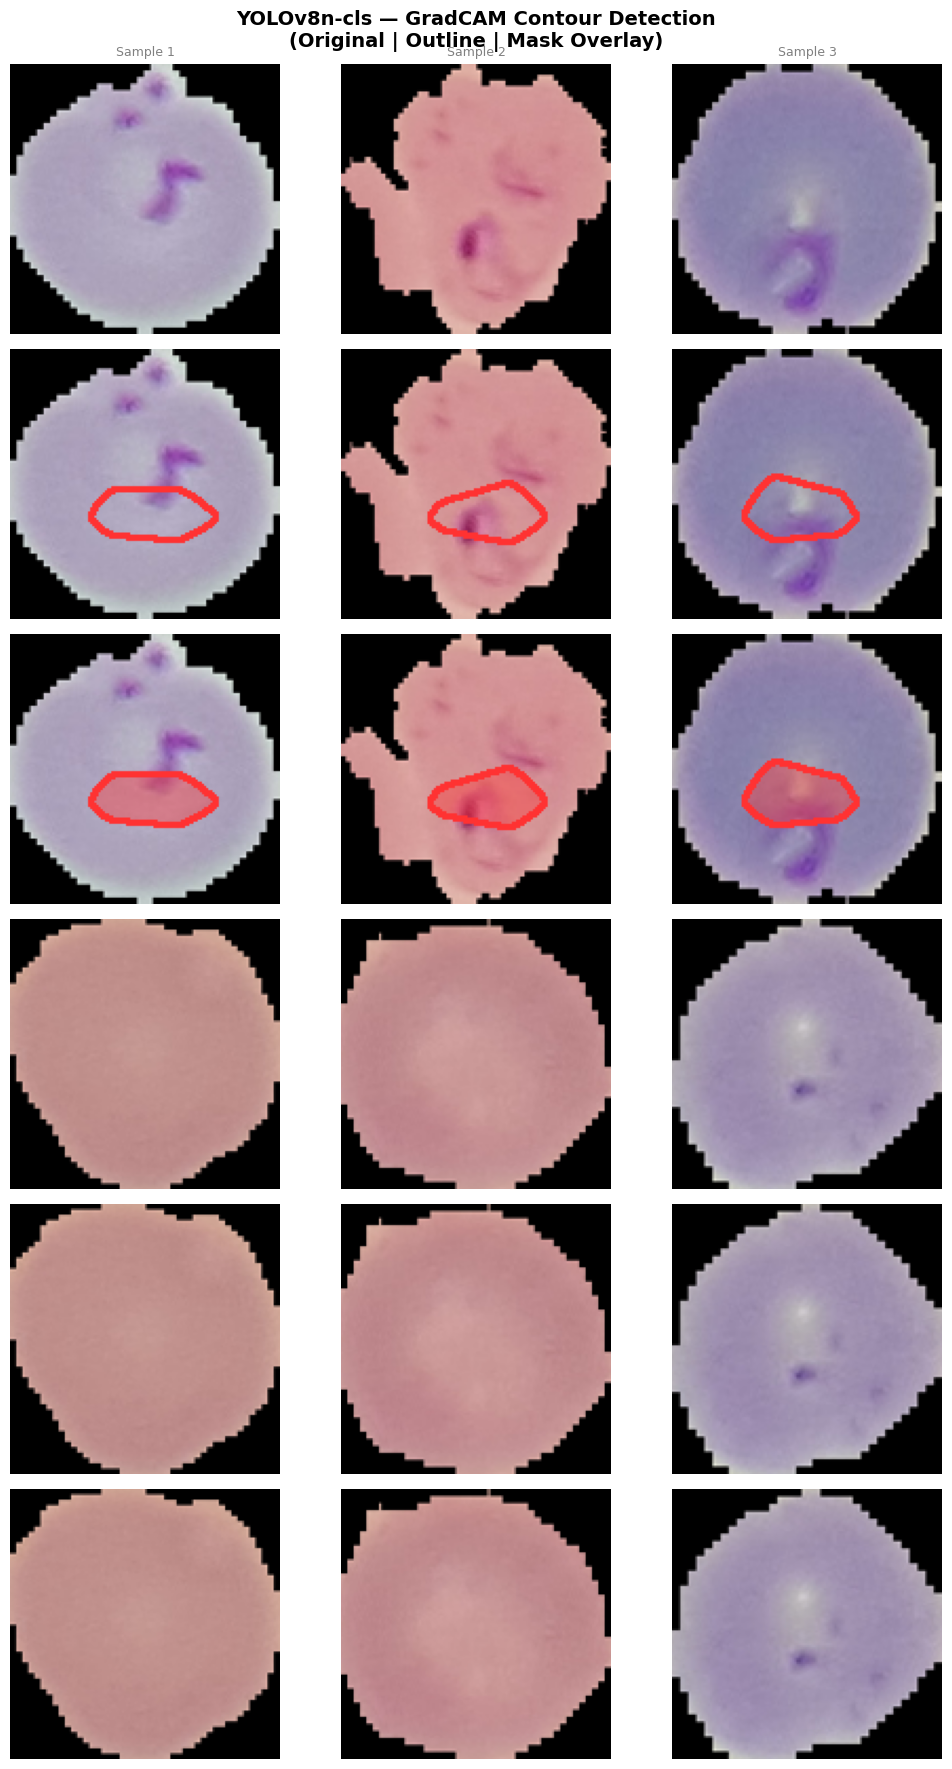


Saved: /kaggle/working/yolo_malaria/gradcam_contour.png


<Figure size 640x480 with 0 Axes>


Saved: /kaggle/working/yolo_malaria/gradcam_contour.png
Tip: Adjust THRESHOLD (currently 0.65) to make outlines tighter or looser.


In [3]:

best_pt     = "/kaggle/working/runs/classify/runs/classify/parasite_cls_128_70_15_15/weights/best.pt"
test_dir    = "/kaggle/working/augmented_horizontal_128_split/test"
OUTPUT_DIR  = "/kaggle/working/yolo_malaria"
CLASS_NAMES = ["Parasitized", "Uninfected"]
IMG_SIZE    = 128
N_SAMPLES   = 3      
SEED        = 42
THRESHOLD   = 0.65   
random.seed(SEED)
os.makedirs(OUTPUT_DIR, exist_ok=True)

class GradCAM:
    def __init__(self, yolo_model):
        self.model       = yolo_model.model
        self.gradients   = None
        self.activations = None
        target_layer = None
        for name, m in self.model.named_modules():
            if isinstance(m, torch.nn.Conv2d) and m.kernel_size != (1, 1):
                target_layer = m
        if target_layer:
            target_layer.register_forward_hook(
                lambda m, i, o: setattr(self, "activations", o.detach()))
            target_layer.register_full_backward_hook(
                lambda m, gi, go: setattr(self, "gradients", go[0].detach()))
            print(f"Hooked: {target_layer}")

    def generate(self, img_tensor, class_idx):
        self.model.eval()
        inp = img_tensor.unsqueeze(0).requires_grad_(True)
        out = self.model(inp)
        if isinstance(out, (list, tuple)): out = out[0]
        if hasattr(out, "logits"):         out = out.logits
        if out.dim() == 1:                 out = out.unsqueeze(0)
        self.model.zero_grad()
        out[0, class_idx].backward()
        if self.gradients is None or self.activations is None:
            return None
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam     = F.relu((self.activations * weights).sum(dim=1, keepdim=True))
        cam     = cam.squeeze().cpu().numpy()
        cam    -= cam.min()
        if cam.max() > 0: cam /= cam.max()
        return cam

def preprocess(img_path):
    img    = Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    tensor = torch.tensor(np.array(img)).permute(2, 0, 1).float() / 255.0
    mean   = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std    = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor - mean) / std

def draw_contour_overlay(img_path, cam, threshold=THRESHOLD):
    """Draw contour outline on original image from GradCAM heatmap."""
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    binary_mask = (cam_resized >= threshold).astype(np.uint8) * 255

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN,  kernel)

    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest  = max(contours, key=cv2.contourArea)
        min_area = 0.01 * IMG_SIZE * IMG_SIZE   # must be > 1% of image
        contours = [largest] if cv2.contourArea(largest) > min_area else []

    
    outlined = img.copy()
    cv2.drawContours(outlined, contours, -1, (255, 50, 50), 2)

    
    mask_overlay = img.copy()
    if contours:
        mask_colored = np.zeros_like(img)
        mask_colored[:, :] = [255, 50, 50]
        filled       = np.where(binary_mask[:, :, None] > 0, mask_colored, img)
        mask_overlay = cv2.addWeighted(img, 0.6, filled.astype(np.uint8), 0.4, 0)
        cv2.drawContours(mask_overlay, contours, -1, (255, 50, 50), 2)

    return img, outlined, mask_overlay
    

gradcam = GradCAM(YOLO(best_pt))

samples = {}
for cls_name in CLASS_NAMES:
    cls_folder = os.path.join(test_dir, cls_name)
    all_imgs   = [os.path.join(cls_folder, f) for f in os.listdir(cls_folder)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    samples[cls_name] = random.sample(all_imgs, N_SAMPLES)



n_rows = len(CLASS_NAMES) * 3   
fig, axes = plt.subplots(n_rows, N_SAMPLES, figsize=(N_SAMPLES * 3.5, n_rows * 3))
fig.suptitle("YOLOv8n-cls — GradCAM Contour Detection\n(Original | Outline | Mask Overlay)",
             fontsize=14, fontweight="bold")

row_labels = [
    "Parasitized\n(Original)",  "Parasitized\n(Outline)",   "Parasitized\n(Mask)",
    "Uninfected\n(Original)",   "Uninfected\n(No Outline)",  "Uninfected\n(No Mask)",
]

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    row_base = cls_idx * 3

    for col, img_path in enumerate(samples[cls_name]):
        cam = gradcam.generate(preprocess(img_path), cls_idx)

        if cam is not None:                                      
            if cls_idx == 0:                                     
                original, outlined, mask_overlay = draw_contour_overlay(img_path, cam)
            else:                                                
                original = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
                original = cv2.resize(original, (IMG_SIZE, IMG_SIZE))
                outlined     = original.copy()
                mask_overlay = original.copy()

            axes[row_base + 0][col].imshow(original)
            axes[row_base + 1][col].imshow(outlined)
            axes[row_base + 2][col].imshow(mask_overlay)

        for r in range(3):
            axes[row_base + r][col].axis("off")
            if col == 0:
                axes[row_base + r][col].set_ylabel(
                    row_labels[row_base + r], fontsize=9, fontweight="bold")

        if cls_idx == 0 and col < N_SAMPLES:
            axes[0][col].set_title(f"Sample {col + 1}", fontsize=9, color="gray")

plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, "gradcam_contour.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"\nSaved: {out_path}")

plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, "gradcam_contour.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"\nSaved: {out_path}")
print(f"Tip: Adjust THRESHOLD (currently {THRESHOLD}) to make outlines tighter or looser.")

In [10]:
# visualize_saliency("/kaggle/working/augmented_horizontal_128_split/test/Parasitized/C100P61ThinF_IMG_20150918_144104_cell_165.png")

## YoloV8-n Deployment

In [9]:
!pip install ultralytics grad-cam -q

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import torchvision.transforms as transforms
import os, random

In [4]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/runs/classify/runs/classify/parasite_cls_128_70_15_15/weights/best.pt")  # update this path
pytorch_model = model.model
pytorch_model.eval()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


ClassificationModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
   

In [19]:
from IPython.display import FileLink
FileLink("/kaggle/working/runs/classify/runs/classify/parasite_cls_128_70_15_15/weights/best.pt")

/kaggle/working/runs/classify/runs/classify/parasite_cls_128_70_15_15/weights/best.pt

In [20]:
# Cell 1 — write app.py
app_code = '''
import gradio as gr
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2
from PIL import Image
from ultralytics import YOLO
import torchvision.transforms as transforms

MODEL_PATH  = "best.pt"
CLASS_NAMES = ["Parasitized", "Uninfected"]
IMG_SIZE    = 128

yolo          = YOLO(MODEL_PATH)
pytorch_model = yolo.model
pytorch_model.eval()

class GradCAM:
    def __init__(self, model):
        self.model       = model
        self.gradients   = None
        self.activations = None
        target_layer = None
        for name, m in self.model.named_modules():
            if isinstance(m, torch.nn.Conv2d) and m.kernel_size != (1, 1):
                target_layer = m
        if target_layer:
            target_layer.register_forward_hook(
                lambda m, i, o: setattr(self, "activations", o.detach()))
            target_layer.register_full_backward_hook(
                lambda m, gi, go: setattr(self, "gradients", go[0].detach()))

    def generate(self, img_tensor, class_idx):
        self.model.eval()
        inp = img_tensor.unsqueeze(0).requires_grad_(True)
        out = self.model(inp)
        if isinstance(out, (list, tuple)): out = out[0]
        if hasattr(out, "logits"):         out = out.logits
        if out.dim() == 1:                 out = out.unsqueeze(0)
        self.model.zero_grad()
        out[0, class_idx].backward()
        if self.gradients is None or self.activations is None:
            return None
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam     = F.relu((self.activations * weights).sum(dim=1, keepdim=True))
        cam     = cam.squeeze().cpu().numpy()
        cam    -= cam.min()
        if cam.max() > 0: cam /= cam.max()
        return cam

gradcam = GradCAM(pytorch_model)

def preprocess(img):
    img    = img.resize((IMG_SIZE, IMG_SIZE))
    tensor = torch.tensor(np.array(img)).permute(2, 0, 1).float() / 255.0
    mean   = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std    = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor - mean) / std

def predict(image):
    img    = image.convert("RGB")
    tensor = preprocess(img)

    with torch.no_grad():
        out = pytorch_model(tensor.unsqueeze(0))
        if isinstance(out, (list, tuple)): out = out[0]
        probs      = torch.softmax(out, dim=1)[0]
        pred_class = probs.argmax().item()
        confidence = probs[pred_class].item()

    label  = CLASS_NAMES[pred_class]
    scores = {CLASS_NAMES[i]: float(f"{probs[i].item():.4f}") for i in range(len(CLASS_NAMES))}

    cam      = gradcam.generate(tensor, pred_class)
    original = np.array(img.resize((IMG_SIZE, IMG_SIZE))).astype(np.float32) / 255.0

    if cam is not None:
        cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
        heatmap     = cv2.applyColorMap((cam_resized * 255).astype(np.uint8), cv2.COLORMAP_JET)
        heatmap     = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        overlay     = np.clip((0.55 * original + 0.45 * heatmap) * 255, 0, 255).astype(np.uint8)
        overlay_img = Image.fromarray(overlay)
    else:
        overlay_img = img.resize((IMG_SIZE, IMG_SIZE))

    result_text = f"Prediction: {label}\\nConfidence: {confidence:.1%}"
    return overlay_img, scores, result_text

with gr.Blocks(title="Malaria Cell Classifier") as demo:
    gr.Markdown("""
    # Malaria Cell Classifier
    ### YOLOv8-n with GradCAM Explainability
    Upload a blood smear cell image to detect **Parasitized** or **Uninfected** cells.
    The GradCAM overlay highlights the regions the model focused on to make its prediction.
    """)
    with gr.Row():
        with gr.Column():
            image_input = gr.Image(type="pil", label="Upload cell image")
            submit_btn  = gr.Button("Classify", variant="primary")
        with gr.Column():
            gradcam_out = gr.Image(label="GradCAM overlay")
            result_out  = gr.Textbox(label="Prediction", lines=2)
            scores_out  = gr.Label(label="Confidence scores")
    submit_btn.click(fn=predict, inputs=image_input, outputs=[gradcam_out, scores_out, result_out])

demo.launch()
'''

with open("/kaggle/working/app.py", "w") as f:
    f.write(app_code)
print("app.py saved")

app.py saved


In [21]:
#  requirements.txt
req = """ultralytics==8.0.235
gradio
torch
torchvision
opencv-python-headless
Pillow
numpy
"""
with open("/kaggle/working/requirements.txt", "w") as f:
    f.write(req)
print("requirements.txt saved")

requirements.txt saved


In [22]:
#  README.md
readme = """---
title: Malaria Cell Classifier 
colorFrom: red
colorTo: blue
sdk: gradio
sdk_version: 4.0.0
app_file: app.py
pinned: false
---

# Malaria Cell Classifier — YOLOv8-n

This app classifies blood smear cell images as **Parasitized** or **Uninfected**
using a YOLOv8-n model trained on the NIH Malaria Cell Images dataset.

## Model performance
| Class | Precision | Recall | F1 |
|---|---|---|---|
| Parasitized | 0.98 | 0.97 | 0.98 |
| Uninfected | 0.97 | 0.98 | 0.98 |

## Explainability
GradCAM heatmaps highlight the regions of the cell the model focused
on when making each prediction.

## Dataset
NIH Malaria Cell Images dataset via Kaggle.
"""
with open("/kaggle/working/README.md", "w") as f:
    f.write(readme)
print("README.md saved")

README.md saved


In [23]:
import shutil
from IPython.display import FileLink, display

src = "/kaggle/working/runs/classify/runs/classify/parasite_cls_128_70_15_15/weights/best.pt"
dst = "/kaggle/working/best.pt"
shutil.copy(src, dst)
print("best.pt copied\n")

print("Download your files:")
display(FileLink("app.py"))
display(FileLink("requirements.txt"))
display(FileLink("README.md"))
display(FileLink("best.pt"))

best.pt copied

Download your files:


/kaggle/working/app.py

/kaggle/working/requirements.txt

/kaggle/working/README.md

/kaggle/working/best.pt